# Language probe visualizations

Held-out results for the six-way language probe: Gisu, Kinyarwanda, Luganda, Lusoga, Runyankore, and Swahili. Activations are read at the name in `The name {name} comes from`. Chance is 1/6. The character n-gram baseline is fit on the name string alone, with the same train and test split.

Source: `results/language_mech/`.

In [1]:
%matplotlib inline

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "results" / "language_mech").is_dir():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("results/language_mech not found")

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

FILES = [
    ("distilgpt2.json", "distilgpt2"),
    ("HuggingFaceTB__SmolLM2-360M.json", "SmolLM2-360M"),
    ("Qwen__Qwen3-0.6B.json", "Qwen3-0.6B"),
    ("Qwen__Qwen2.5-0.5B.json", "Qwen2.5-0.5B"),
]
runs = []
for filename, label in FILES:
    payload = json.loads((ROOT / "results" / "language_mech" / filename).read_text())
    if payload.get("error"):
        raise RuntimeError(f"{label}: {payload['error']}")
    payload["label"] = label
    runs.append(payload)

CHANCE = 1 / 6
CHAR_NGRAM = runs[0]["orthography"]["full"]["accuracy"]
LANG_ORDER = ["gisu", "kinyarwanda", "luganda", "lusoga", "runyankore", "swahili"]
LANG_LABELS = ["Gisu", "Kinyarwanda", "Luganda", "Lusoga", "Runyankore", "Swahili"]
COLORS = {
    "distilgpt2": "#0072B2",
    "SmolLM2-360M": "#E69F00",
    "Qwen3-0.6B": "#009E73",
    "Qwen2.5-0.5B": "#CC79A7",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
    "legend.frameon": False,
})


def finish(fig, name):
    path = FIG / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(path.relative_to(ROOT))


## Accuracy by layer

Each point is a linear probe on the residual at the last piece of the name. The probe is fit on the training split and scored on the test split.

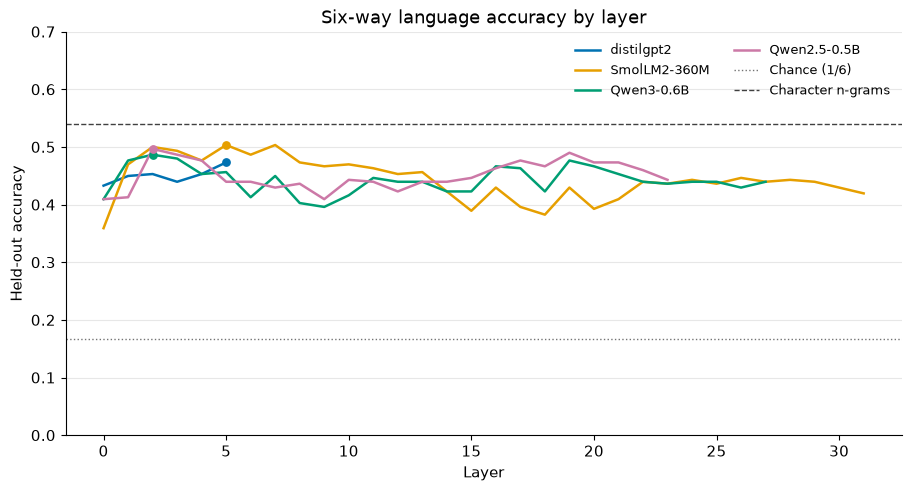

results/figures/accuracy_by_layer.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
for run in runs:
    curve = run["positions"]["last"]["by_layer"]
    layers = np.arange(len(curve))
    ax.plot(layers, curve, color=COLORS[run["label"]], label=run["label"], linewidth=1.8)
    best = run["positions"]["last"]["best_layer"]
    ax.scatter([best], [curve[best]], color=COLORS[run["label"]], zorder=3, s=28)
ax.axhline(CHANCE, color="0.45", linewidth=1, linestyle=":", label="Chance (1/6)")
ax.axhline(CHAR_NGRAM, color="0.25", linewidth=1, linestyle="--", label="Character n-grams")
ax.set_title("Six-way language accuracy by layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Held-out accuracy")
ax.set_ylim(0, 0.7)
ax.yaxis.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9)
finish(fig, "accuracy_by_layer.png")


## Where the name is read

The last piece is the probe used above. The first piece and the mean use the same residual, taken over the tokenizer pieces inside the name. Character n-grams and token count do not use the model.

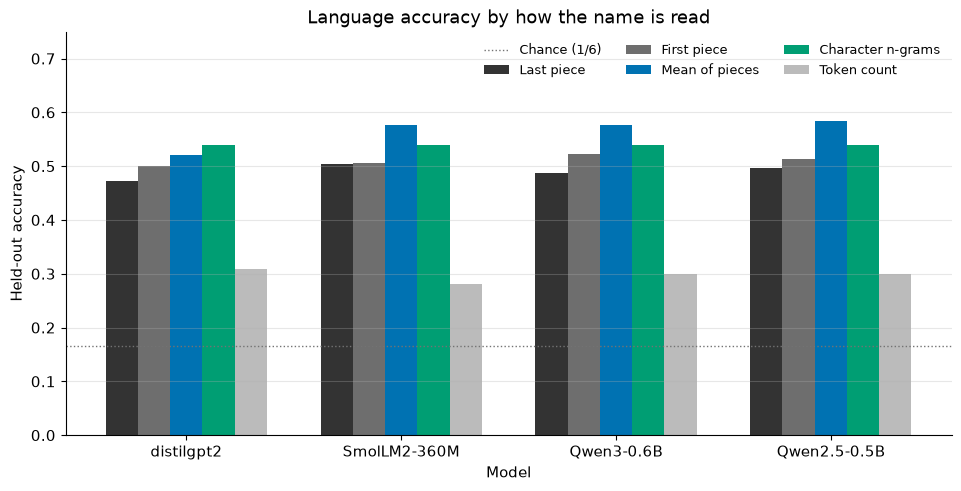

results/figures/readout_comparison.png


In [3]:
series = [
    ("Last piece", lambda run: run["positions"]["last"]["accuracy"]),
    ("First piece", lambda run: run["positions"]["first"]["accuracy"]),
    ("Mean of pieces", lambda run: run["positions"]["mean"]["accuracy"]),
    ("Character n-grams", lambda run: run["orthography"]["full"]["accuracy"]),
    ("Token count", lambda run: run["token_count_baseline"]),
]
x = np.arange(len(runs))
width = 0.15
fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
bar_colors = ["#333333", "#6e6e6e", "#0072B2", "#009E73", "#bbbbbb"]
for index, (name, getter) in enumerate(series):
    offset = (index - (len(series) - 1) / 2) * width
    values = [getter(run) for run in runs]
    ax.bar(x + offset, values, width, label=name, color=bar_colors[index])
ax.axhline(CHANCE, color="0.45", linewidth=1, linestyle=":", label="Chance (1/6)")
ax.set_title("Language accuracy by how the name is read")
ax.set_xlabel("Model")
ax.set_ylabel("Held-out accuracy")
ax.set_xticks(x, [run["label"] for run in runs])
ax.set_ylim(0, 0.75)
ax.yaxis.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=9)
finish(fig, "readout_comparison.png")


## Recall by language

Recall at the best last-piece layer. A language at the chance level would be near 1/6.

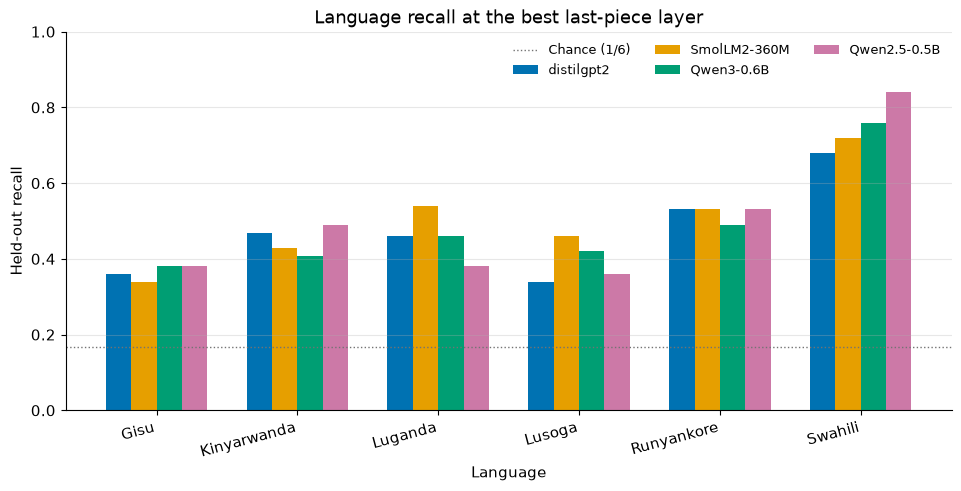

results/figures/recall_by_language.png


In [4]:
x = np.arange(len(LANG_ORDER))
width = 0.18
fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
for index, run in enumerate(runs):
    offset = (index - (len(runs) - 1) / 2) * width
    values = [run["clean_language"]["recall"][code] for code in LANG_ORDER]
    ax.bar(x + offset, values, width, label=run["label"], color=COLORS[run["label"]])
ax.axhline(CHANCE, color="0.45", linewidth=1, linestyle=":", label="Chance (1/6)")
ax.set_title("Language recall at the best last-piece layer")
ax.set_xlabel("Language")
ax.set_ylabel("Held-out recall")
ax.set_xticks(x, LANG_LABELS, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.yaxis.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=9)
finish(fig, "recall_by_language.png")


## Ablation

At the best last-piece layer, the fitted language probe uses five directions. "Same probe" scores that probe after the directions are removed. "Refit" trains a new probe on the altered activations. The random bar removes five random directions and refits.

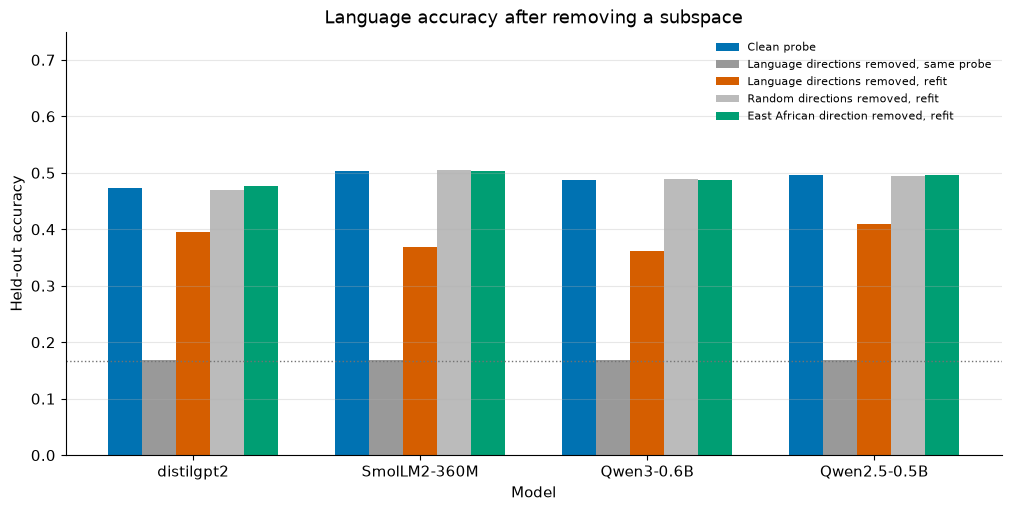

results/figures/ablation.png


In [5]:
ablation_series = [
    ("Clean probe", lambda run: run["clean_language"]["accuracy"]),
    ("Language directions removed, same probe", lambda run: run["ablation"]["language_subspace"]["language_original"]),
    ("Language directions removed, refit", lambda run: run["ablation"]["language_subspace"]["language_refit"]),
    ("Random directions removed, refit", lambda run: run["ablation"]["random_subspace"]["language_refit"]),
    ("East African direction removed, refit", lambda run: run["ablation"]["binary_direction"]["language_refit"]),
]
x = np.arange(len(runs))
width = 0.15
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bar_colors = ["#0072B2", "#999999", "#D55E00", "#bbbbbb", "#009E73"]
for index, (name, getter) in enumerate(ablation_series):
    offset = (index - (len(ablation_series) - 1) / 2) * width
    values = [getter(run) for run in runs]
    ax.bar(x + offset, values, width, label=name, color=bar_colors[index])
ax.axhline(CHANCE, color="0.45", linewidth=1, linestyle=":")
ax.set_title("Language accuracy after removing a subspace")
ax.set_xlabel("Model")
ax.set_ylabel("Held-out accuracy")
ax.set_xticks(x, [run["label"] for run in runs])
ax.set_ylim(0, 0.75)
ax.yaxis.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper right")
finish(fig, "ablation.png")


## Activation patching

Each test name is paired with a name from another language. The residual at the last piece of the name is replaced with the other name's residual, at one layer. The probe then predicts a language. The solid line is how often that prediction is the source language. The dashed line is how often it is still the destination language. The dotted line is the direct-copy ceiling: the probe's accuracy on the source vector itself.

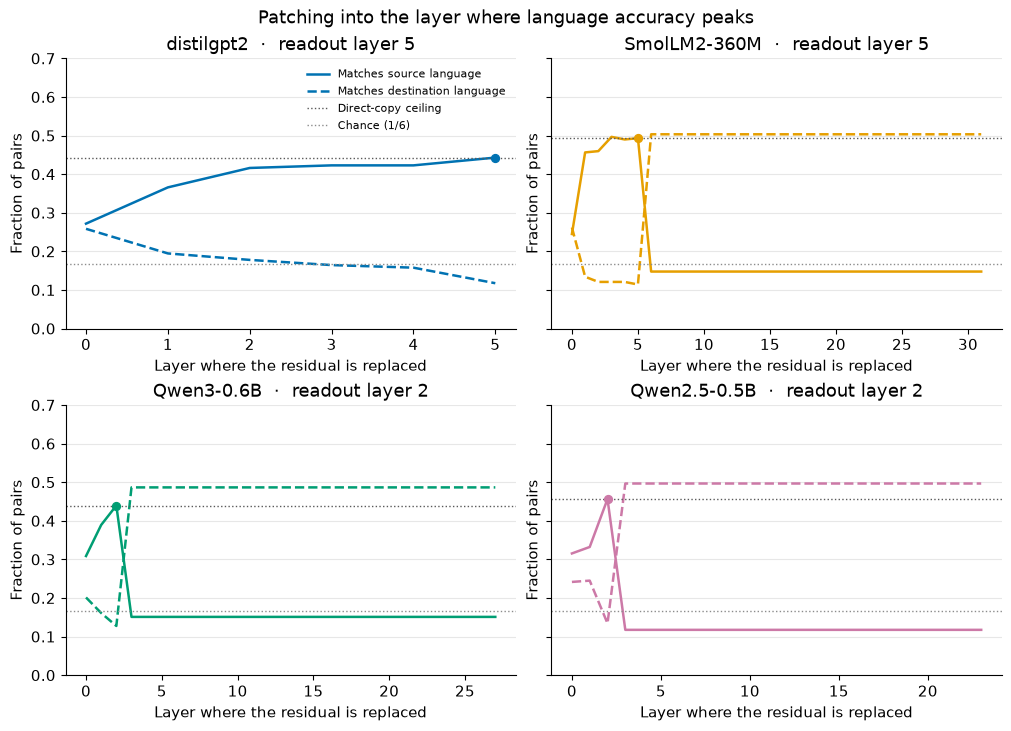

results/figures/patching_best_layer.png


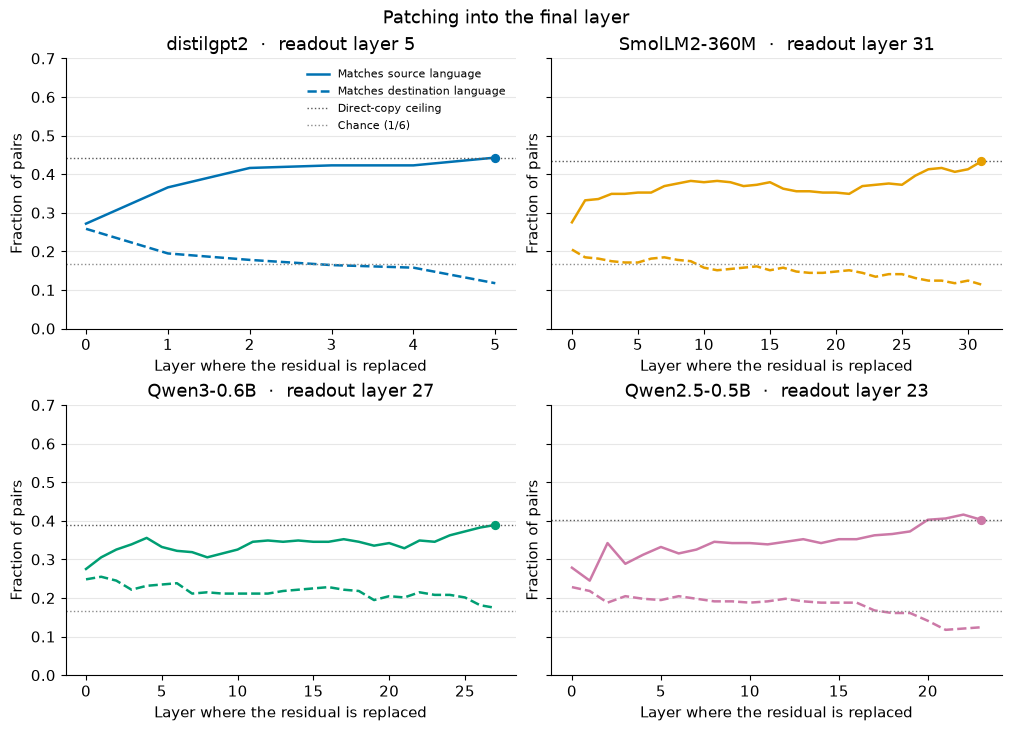

results/figures/patching_final_layer.png


In [6]:
def patch_figure(layer_of, title, filename):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7.2), sharey=True, constrained_layout=True)
    for ax, run in zip(axes.ravel(), runs):
        layer = layer_of(run)
        curve = run["patching"]["curves"][str(layer)]
        meta = run["patching"]["by_readout"][str(layer)]
        xs = [row["layer"] for row in curve]
        color = COLORS[run["label"]]
        ax.plot(xs, [row["source_match"] for row in curve], color=color, linewidth=1.8, label="Matches source language")
        ax.plot(
            xs,
            [row["dest_match"] for row in curve],
            color=color,
            linewidth=1.8,
            linestyle="--",
            label="Matches destination language",
        )
        ax.axhline(meta["source_ceiling"], color="0.35", linewidth=1, linestyle=":", label="Direct-copy ceiling")
        ax.axhline(CHANCE, color="0.55", linewidth=1, linestyle=":", label="Chance (1/6)")
        copied = [row for row in curve if row["direct_copy"]]
        if copied:
            ax.scatter(
                [copied[0]["layer"]],
                [copied[0]["source_match"]],
                color=color,
                s=32,
                zorder=3,
            )
        ax.set_title(f"{run['label']}  ·  readout layer {layer}")
        ax.set_xlabel("Layer where the residual is replaced")
        ax.set_ylabel("Fraction of pairs")
        ax.set_ylim(0, 0.7)
        ax.yaxis.grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(title)
    finish(fig, filename)


patch_figure(
    lambda run: run["clean_language"]["layer"],
    "Patching into the layer where language accuracy peaks",
    "patching_best_layer.png",
)
patch_figure(
    lambda run: run["clean_language"]["final_layer"],
    "Patching into the final layer",
    "patching_final_layer.png",
)


## Attention and MLP

Separate probes on the attention write and the MLP write at the last piece of the name, compared with the residual at that layer.

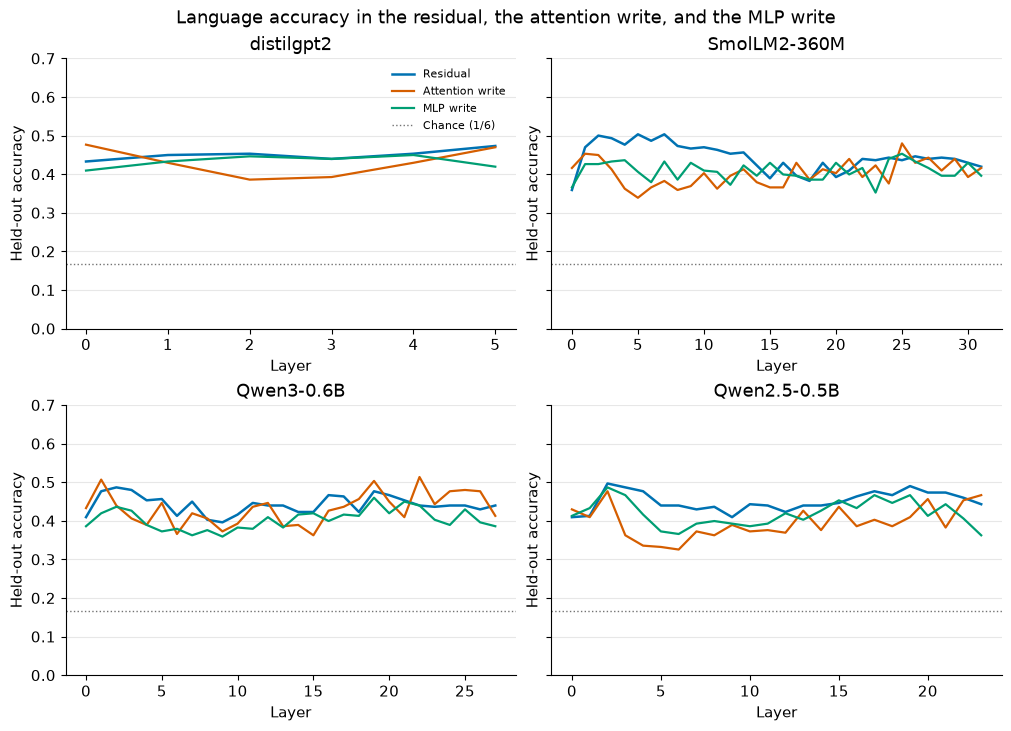

results/figures/component_writes.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.2), sharey=True, constrained_layout=True)
for ax, run in zip(axes.ravel(), runs):
    residual = run["positions"]["last"]["by_layer"]
    attention = run["components"]["attn"]["by_layer"]
    mlp = run["components"]["mlp"]["by_layer"]
    layers = np.arange(len(residual))
    ax.plot(layers, residual, color="#0072B2", linewidth=1.8, label="Residual")
    ax.plot(layers, attention, color="#D55E00", linewidth=1.6, label="Attention write")
    ax.plot(layers, mlp, color="#009E73", linewidth=1.6, label="MLP write")
    ax.axhline(CHANCE, color="0.45", linewidth=1, linestyle=":", label="Chance (1/6)")
    ax.set_title(run["label"])
    ax.set_xlabel("Layer")
    ax.set_ylabel("Held-out accuracy")
    ax.set_ylim(0, 0.7)
    ax.yaxis.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Language accuracy in the residual, the attention write, and the MLP write")
finish(fig, "component_writes.png")


## Confusion, significance, and a spelling control

The layer in these plots is chosen by training accuracy, then scored on the test names. Character n-grams are the spelling baseline. The shuffle keeps each name's letters and length but destroys their order.

Source: `results/paper_strength/`.

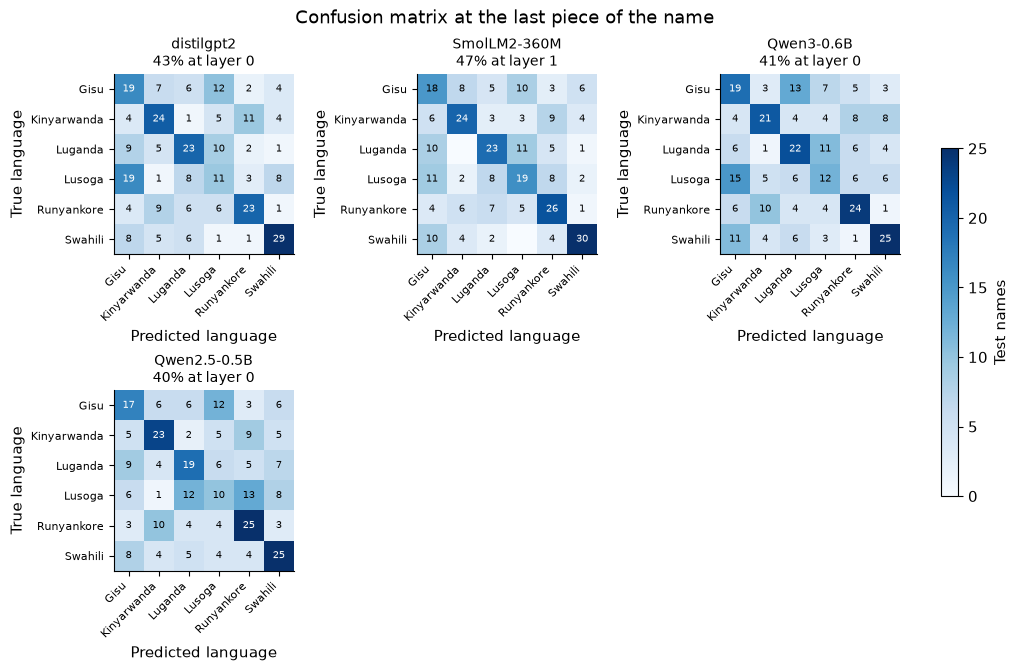

results/figures/confusion_last.png


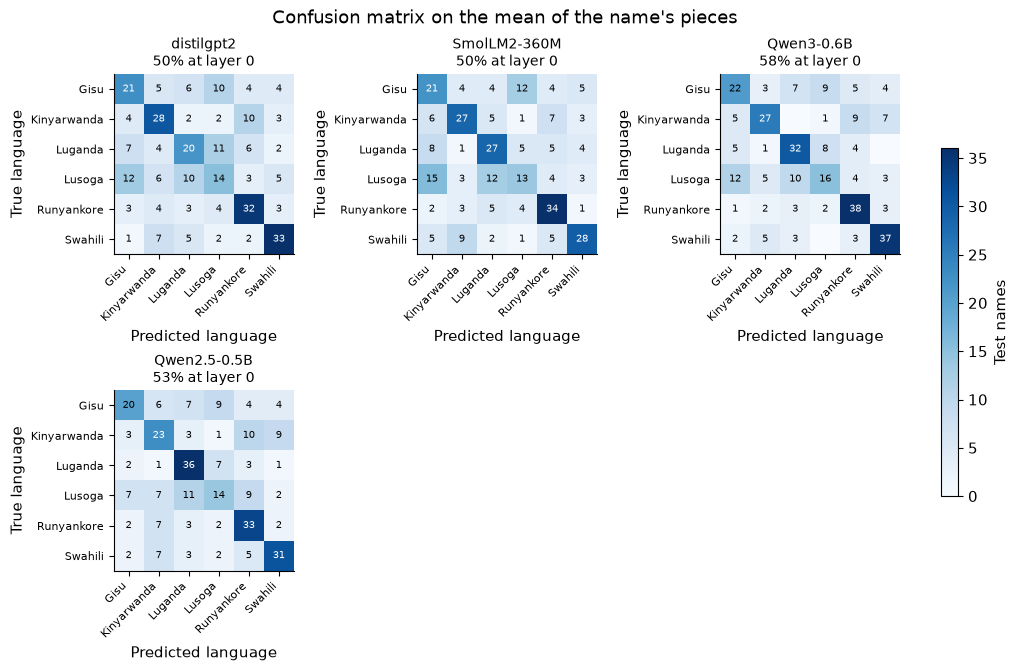

results/figures/confusion_mean.png


In [8]:
from math import ceil

STRENGTH_FILES = [
    ("distilgpt2.json", "distilgpt2"),
    ("HuggingFaceTB__SmolLM2-360M.json", "SmolLM2-360M"),
    ("Qwen__Qwen3-0.6B.json", "Qwen3-0.6B"),
    ("Qwen__Qwen2.5-0.5B.json", "Qwen2.5-0.5B"),
    ("Qwen__Qwen2.5-1.5B.json", "Qwen2.5-1.5B"),
]
STRENGTH_COLORS = {
    "distilgpt2": "#0072B2",
    "SmolLM2-360M": "#E69F00",
    "Qwen3-0.6B": "#009E73",
    "Qwen2.5-0.5B": "#CC79A7",
    "Qwen2.5-1.5B": "#D55E00",
}
strength = []
for filename, label in STRENGTH_FILES:
    path = ROOT / "results" / "paper_strength" / filename
    if not path.exists():
        continue
    payload = json.loads(path.read_text())
    if payload.get("error"):
        raise RuntimeError(f"{label}: {payload['error']}")
    payload["label"] = label
    strength.append(payload)
if not strength:
    raise FileNotFoundError("results/paper_strength is empty")

LANGS = strength[0]["languages"]
LANG_TICKS = [name.capitalize() if name != "kinyarwanda" else "Kinyarwanda" for name in LANGS]
LANG_TICKS = ["Gisu", "Kinyarwanda", "Luganda", "Lusoga", "Runyankore", "Swahili"]


def confusion_figure(site, title, filename):
    columns = 3 if len(strength) > 3 else len(strength)
    rows = ceil(len(strength) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(3.4 * columns, 3.3 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    image = None
    for ax, run in zip(axes, strength):
        matrix = np.asarray(run[site]["confusion"], dtype=float)
        image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                count = int(matrix[i, j])
                if count == 0:
                    continue
                color = "white" if count > matrix.max() * 0.6 else "black"
                ax.text(j, i, str(count), ha="center", va="center", fontsize=7, color=color)
        ax.set_title(f"{run['label']}\n{run[site]['accuracy']:.0%} at layer {run[site]['layer']}", fontsize=10)
        ax.set_xlabel("Predicted language")
        ax.set_ylabel("True language")
        ax.set_xticks(range(len(LANG_TICKS)), LANG_TICKS, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(LANG_TICKS)), LANG_TICKS, fontsize=8)
    for ax in axes[len(strength):]:
        ax.axis("off")
    fig.colorbar(image, ax=axes[: len(strength)].tolist(), shrink=0.7, label="Test names")
    fig.suptitle(title)
    finish(fig, filename)


confusion_figure("last", "Confusion matrix at the last piece of the name", "confusion_last.png")
confusion_figure("mean", "Confusion matrix on the mean of the name's pieces", "confusion_mean.png")


## Probe versus spelling

Each point is the test-set accuracy of the residual probe minus the character n-gram accuracy. The interval is a 95% bootstrap over test names. An interval that stays above zero means the probe beats spelling. McNemar's test uses the same paired names.

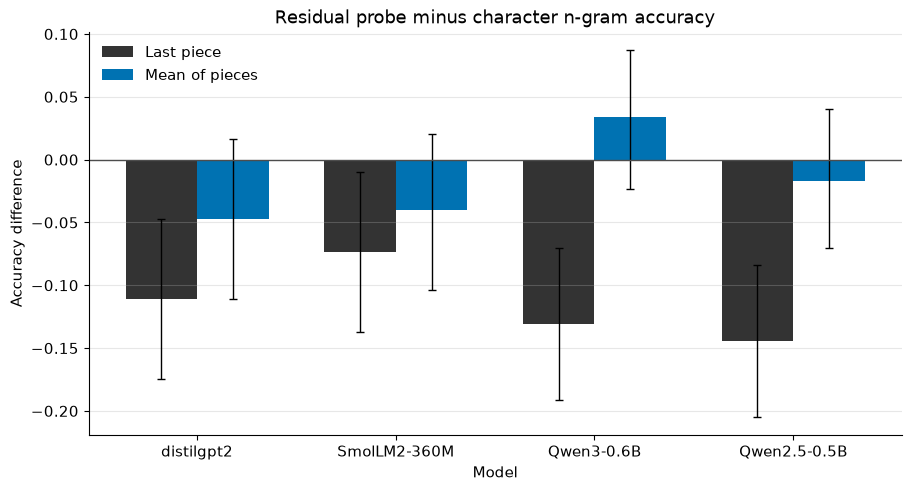

results/figures/probe_minus_ngram.png
model            site   probe  ngram  diff    95% CI             p       
distilgpt2       last   0.433  0.544  -0.111  [-0.174, -0.047]  0.000925
distilgpt2       mean   0.497  0.544  -0.047  [-0.111, +0.017]  0.18
SmolLM2-360M     last   0.470  0.544  -0.074  [-0.138, -0.010]  0.0315
SmolLM2-360M     mean   0.503  0.544  -0.040  [-0.104, +0.020]  0.251
Qwen3-0.6B       last   0.413  0.544  -0.131  [-0.191, -0.070]  6.47e-05
Qwen3-0.6B       mean   0.577  0.544  +0.034  [-0.023, +0.087]  0.289
Qwen2.5-0.5B     last   0.399  0.544  -0.144  [-0.205, -0.084]  1.18e-05
Qwen2.5-0.5B     mean   0.527  0.544  -0.017  [-0.070, +0.040]  0.635


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
x = np.arange(len(strength))
width = 0.36
for offset, site, color in ((-width / 2, "last", "#333333"), (width / 2, "mean", "#0072B2")):
    diffs, lows, highs = [], [], []
    for run in strength:
        compared = run[site]["vs_char_ngram"]
        diffs.append(compared["difference"])
        lows.append(compared["difference"] - compared["bootstrap_ci95"][0])
        highs.append(compared["bootstrap_ci95"][1] - compared["difference"])
    ax.bar(
        x + offset,
        diffs,
        width,
        yerr=np.vstack([lows, highs]),
        color=color,
        label="Last piece" if site == "last" else "Mean of pieces",
        capsize=3,
        error_kw={"linewidth": 1},
    )
ax.axhline(0, color="0.3", linewidth=1)
ax.set_title("Residual probe minus character n-gram accuracy")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy difference")
ax.set_xticks(x, [run["label"] for run in strength])
ax.yaxis.grid(True, alpha=0.3)
ax.legend()
finish(fig, "probe_minus_ngram.png")

print(f"{'model':16} {'site':6} {'probe':6} {'ngram':6} {'diff':7} {'95% CI':18} {'p':8}")
for run in strength:
    for site in ("last", "mean"):
        compared = run[site]["vs_char_ngram"]
        low, high = compared["bootstrap_ci95"]
        print(
            f"{run['label']:16} {site:6} {compared['model_accuracy']:.3f}  "
            f"{compared['ngram_accuracy']:.3f}  {compared['difference']:+.3f}  "
            f"[{low:+.3f}, {high:+.3f}]  {compared['mcnemar_p']:.3g}"
        )


## Shuffled letters

Each name keeps its own letters and its length. Their order is shuffled, and the language label stays the same. If the probe was reading letter order, accuracy should fall to chance.

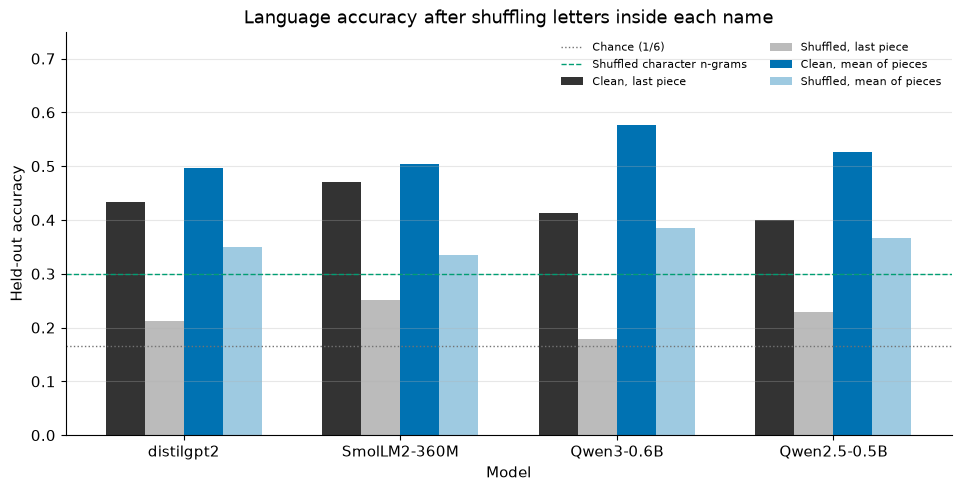

results/figures/shuffled_letters.png


In [10]:
series = [
    ("Clean, last piece", lambda run: run["last"]["accuracy"], "#333333"),
    ("Shuffled, last piece", lambda run: run["shuffled"]["last"]["accuracy_at_clean_layer"], "#bbbbbb"),
    ("Clean, mean of pieces", lambda run: run["mean"]["accuracy"], "#0072B2"),
    ("Shuffled, mean of pieces", lambda run: run["shuffled"]["mean"]["accuracy_at_clean_layer"], "#9ecae1"),
]
x = np.arange(len(strength))
width = 0.18
fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
for index, (name, getter, color) in enumerate(series):
    offset = (index - (len(series) - 1) / 2) * width
    ax.bar(x + offset, [getter(run) for run in strength], width, label=name, color=color)
ax.axhline(1 / 6, color="0.45", linewidth=1, linestyle=":", label="Chance (1/6)")
ax.axhline(strength[0]["shuffled"]["char_2_3gram"], color="#009E73", linewidth=1, linestyle="--", label="Shuffled character n-grams")
ax.set_title("Language accuracy after shuffling letters inside each name")
ax.set_xlabel("Model")
ax.set_ylabel("Held-out accuracy")
ax.set_xticks(x, [run["label"] for run in strength])
ax.set_ylim(0, 0.75)
ax.yaxis.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
finish(fig, "shuffled_letters.png")


## English controls in the language subspace

The subspace is the span of the six training language centroids. English is the control given names. The first curve is the distance from the English centroid to that subspace, divided by the average gap between language centroids. A value near zero means the English centroid lies in the same subspace. The second curve compares how far individual test names sit off the subspace: English divided by the six languages.

The layer marked on each curve is the one with the highest training accuracy for the six-way probe. Source: `results/english_subspace/`.

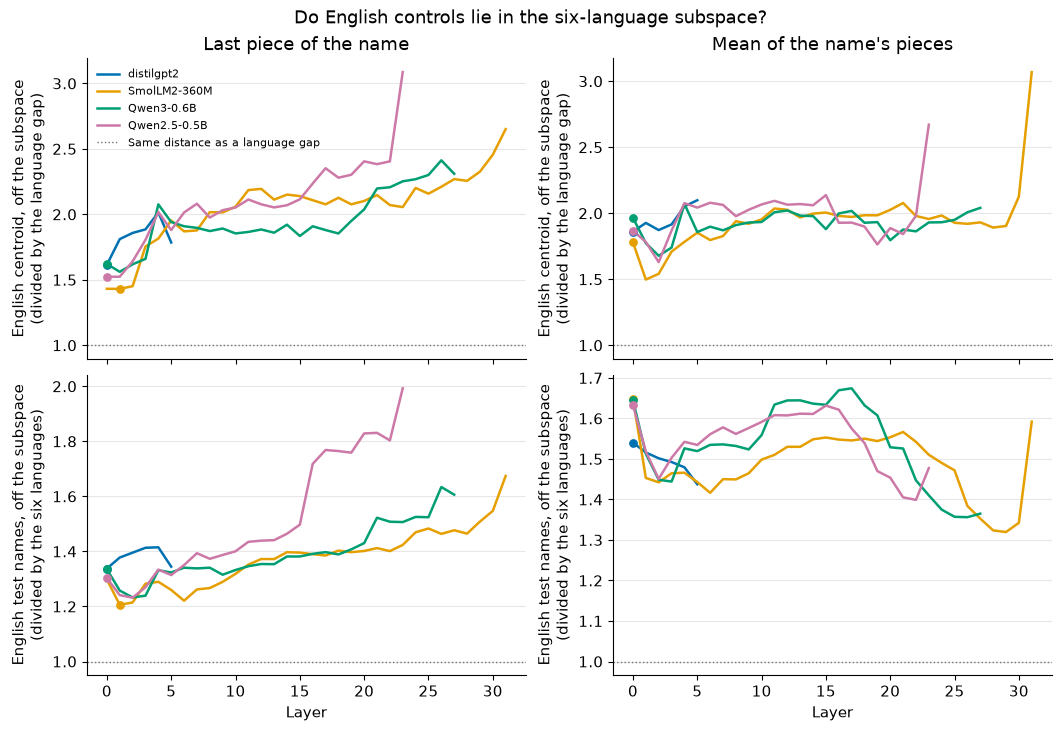

results/figures/english_subspace_distance.png


In [11]:
ENGLISH_FILES = [
    ("distilgpt2.json", "distilgpt2"),
    ("HuggingFaceTB__SmolLM2-360M.json", "SmolLM2-360M"),
    ("Qwen__Qwen3-0.6B.json", "Qwen3-0.6B"),
    ("Qwen__Qwen2.5-0.5B.json", "Qwen2.5-0.5B"),
]
english_runs = []
for filename, label in ENGLISH_FILES:
    path = ROOT / "results" / "english_subspace" / filename
    payload = json.loads(path.read_text())
    if payload.get("error"):
        raise RuntimeError(f"{label}: {payload['error']}")
    payload["label"] = label
    english_runs.append(payload)

GROUP_COLORS = {
    "gisu": "#0072B2",
    "kinyarwanda": "#E69F00",
    "luganda": "#009E73",
    "lusoga": "#CC79A7",
    "runyankore": "#D55E00",
    "swahili": "#56B4E9",
    "english": "#222222",
}
GROUP_LABELS = {
    "gisu": "Gisu",
    "kinyarwanda": "Kinyarwanda",
    "luganda": "Luganda",
    "lusoga": "Lusoga",
    "runyankore": "Runyankore",
    "swahili": "Swahili",
    "english": "English",
}

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2), sharex="col", constrained_layout=True)
metrics = [
    ("english_orthogonal_over_language_gap", "English centroid, off the subspace\n(divided by the language gap)", 1.0, "Same distance as a language gap"),
    ("english_test_orthogonal_over_language_test", "English test names, off the subspace\n(divided by the six languages)", 1.0, "Same as the six languages"),
]
for column, site in enumerate(("last", "mean")):
    for row, (key, ylabel, guide, guide_label) in enumerate(metrics):
        ax = axes[row, column]
        for run in english_runs:
            curve = run[site]["by_layer"]
            layers = [item["layer"] for item in curve]
            values = [item[key] for item in curve]
            ax.plot(layers, values, color=COLORS[run["label"]], label=run["label"], linewidth=1.8)
            chosen = run[site]["layer"]
            ax.scatter([chosen], [curve[chosen][key]], color=COLORS[run["label"]], s=28, zorder=3)
        ax.axhline(guide, color="0.45", linewidth=1, linestyle=":", label=guide_label)
        ax.set_ylabel(ylabel)
        ax.yaxis.grid(True, alpha=0.3)
        if row == 0:
            title = "Last piece of the name" if site == "last" else "Mean of the name's pieces"
            ax.set_title(title)
        if row == 1:
            ax.set_xlabel("Layer")
axes[0, 0].legend(fontsize=8, ncol=1)
fig.suptitle("Do English controls lie in the six-language subspace?")
finish(fig, "english_subspace_distance.png")


## The control direction and the language plane

Each point is the fraction of the six-languages-versus-control direction that lies inside the language subspace. A value near zero means that direction is a different axis from the one the six languages span.

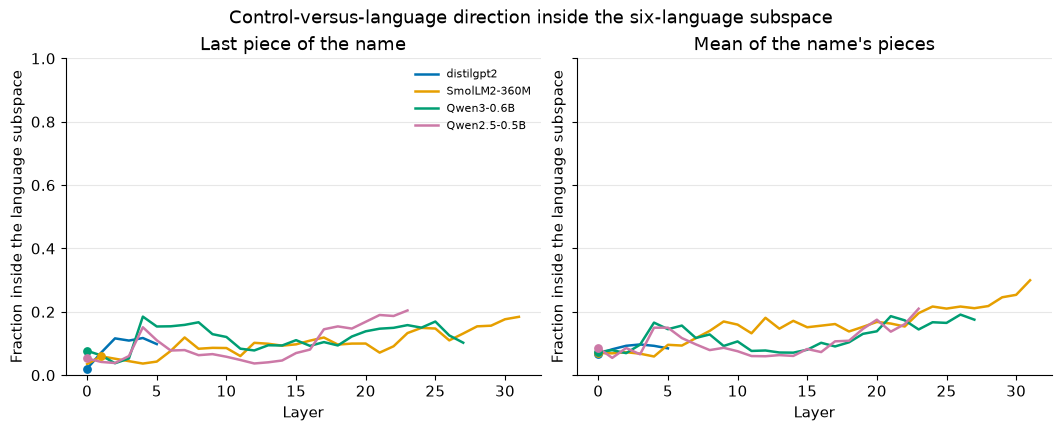

results/figures/english_direction_overlap.png
model            site   layer off-plane in-plane  cloud   overlap  7-way dim
distilgpt2       last   0     1.615     0.253     1.338   0.021    6
distilgpt2       mean   0     1.861     0.522     1.540   0.068    6
SmolLM2-360M     last   1     1.431     0.388     1.206   0.059    6
SmolLM2-360M     mean   0     1.779     0.567     1.648   0.070    6
Qwen3-0.6B       last   0     1.621     0.296     1.335   0.077    6
Qwen3-0.6B       mean   0     1.965     0.583     1.645   0.073    6
Qwen2.5-0.5B     last   0     1.523     0.265     1.303   0.053    6
Qwen2.5-0.5B     mean   0     1.868     0.579     1.633   0.086    6


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, constrained_layout=True)
for ax, site, title in zip(
    axes,
    ("last", "mean"),
    ("Last piece of the name", "Mean of the name's pieces"),
):
    for run in english_runs:
        curve = run[site]["by_layer"]
        layers = [item["layer"] for item in curve]
        values = [item["binary_direction_in_language_subspace"] for item in curve]
        ax.plot(layers, values, color=COLORS[run["label"]], label=run["label"], linewidth=1.8)
        chosen = run[site]["layer"]
        ax.scatter([chosen], [curve[chosen]["binary_direction_in_language_subspace"]], color=COLORS[run["label"]], s=28, zorder=3)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Fraction inside the language subspace")
    ax.yaxis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Control-versus-language direction inside the six-language subspace")
finish(fig, "english_direction_overlap.png")

print(f"{'model':16} {'site':6} {'layer':5} {'off-plane':9} {'in-plane':9} {'cloud':7} {'overlap':8} {'7-way dim':9}")
for run in english_runs:
    for site in ("last", "mean"):
        item = run[site]
        print(
            f"{run['label']:16} {site:6} {item['layer']:<5} "
            f"{item['english_orthogonal_over_language_gap']:.3f}     "
            f"{item['english_inplane_over_language_gap']:.3f}     "
            f"{item['english_test_orthogonal_over_language_test']:.3f}   "
            f"{item['binary_direction_in_language_subspace']:.3f}    "
            f"{item['seven_way_dimension']}"
        )


## Test names projected into the language subspace

Each point is a held-out name, drawn in the two strongest directions of the six-language subspace at the layer chosen above. English is drawn on top. A language centroid that English merely sat beside would land among these clouds. A centroid that sits off the subspace is invisible in this plane, which is what the distance curves measure.

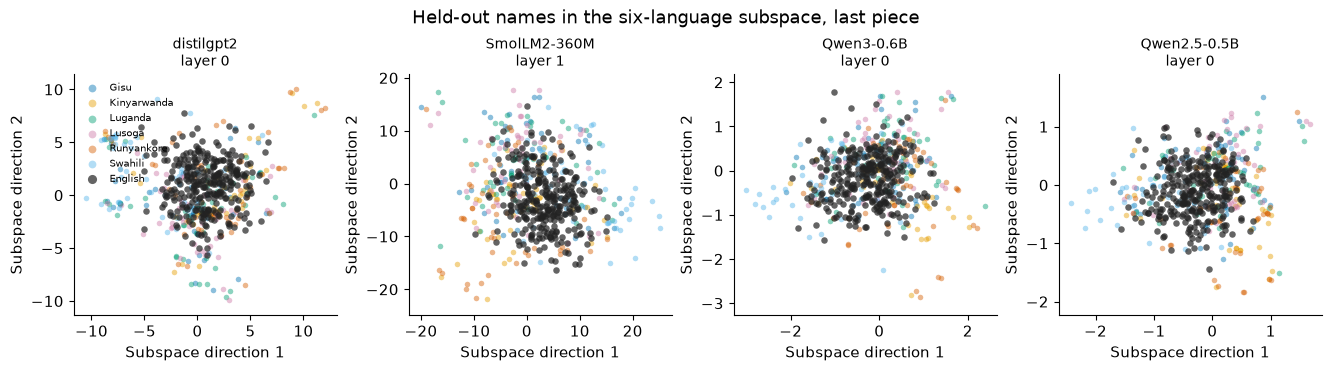

results/figures/english_projection_last.png


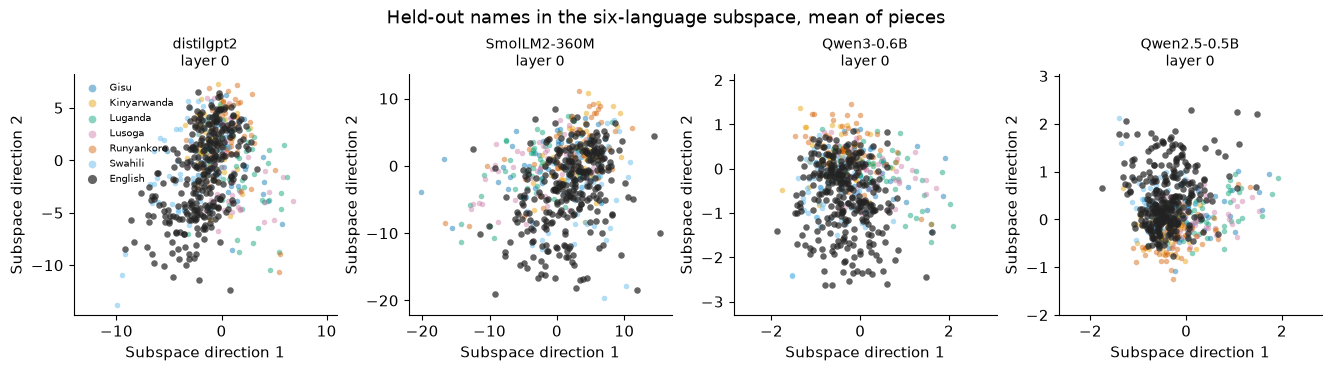

results/figures/english_projection_mean.png


In [13]:
def subspace_scatter(site, title, filename):
    fig, axes = plt.subplots(1, len(english_runs), figsize=(3.3 * len(english_runs), 3.6), constrained_layout=True)
    axes = np.atleast_1d(axes)
    order = ["gisu", "kinyarwanda", "luganda", "lusoga", "runyankore", "swahili", "english"]
    for ax, run in zip(axes, english_runs):
        projection = run[site]["projection"]
        groups = np.asarray(projection["group"])
        x = np.asarray(projection["x"])
        y = np.asarray(projection["y"])
        for name in order:
            mask = groups == name
            ax.scatter(
                x[mask],
                y[mask],
                s=16 if name != "english" else 22,
                alpha=0.45 if name != "english" else 0.7,
                color=GROUP_COLORS[name],
                label=GROUP_LABELS[name],
                linewidths=0,
                zorder=2 if name == "english" else 1,
            )
        ax.set_title(f"{run['label']}\nlayer {run[site]['layer']}", fontsize=10)
        ax.set_xlabel("Subspace direction 1")
        ax.set_ylabel("Subspace direction 2")
        ax.set_aspect("equal", adjustable="datalim")
    axes[0].legend(fontsize=7, loc="upper left", markerscale=1.4)
    fig.suptitle(title)
    finish(fig, filename)

subspace_scatter("last", "Held-out names in the six-language subspace, last piece", "english_projection_last.png")
subspace_scatter("mean", "Held-out names in the six-language subspace, mean of pieces", "english_projection_mean.png")


## Where the six-way probe sends English names

The probe is trained on the six languages only, then asked to label English test names. The counts are how many English names it assigns to each language. High confidence with a spread across languages means the probe has no place to put them, and still picks a language.

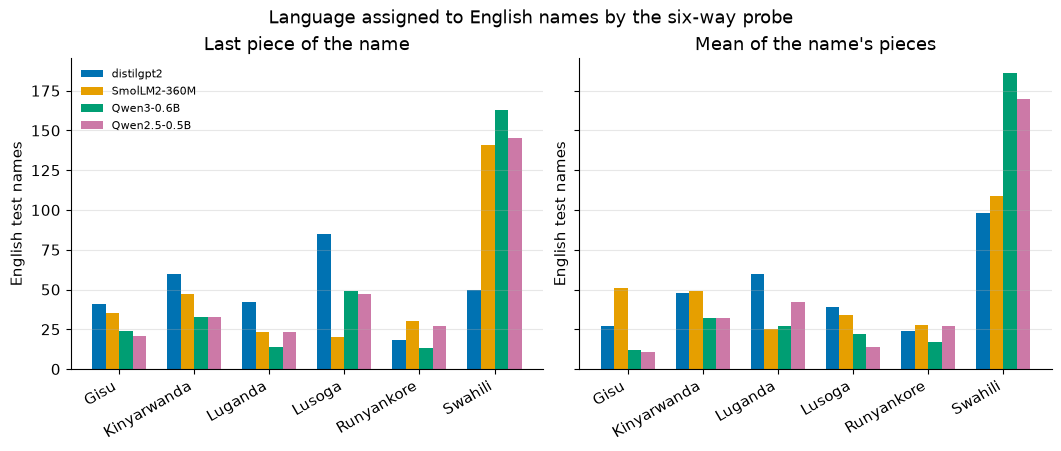

results/figures/english_probe_assignment.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharey=True, constrained_layout=True)
languages = english_runs[0]["languages"]
ticks = [GROUP_LABELS[name] for name in languages]
x = np.arange(len(languages))
width = 0.18
for ax, site, title in zip(
    axes,
    ("last", "mean"),
    ("Last piece of the name", "Mean of the name's pieces"),
):
    for index, run in enumerate(english_runs):
        counts = run[site]["english_assigned_by_six_way_probe"]
        offset = (index - (len(english_runs) - 1) / 2) * width
        ax.bar(x + offset, [counts[name] for name in languages], width, color=COLORS[run["label"]], label=run["label"])
    ax.set_xticks(x, ticks, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel("English test names")
    ax.yaxis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Language assigned to English names by the six-way probe")
finish(fig, "english_probe_assignment.png")


## What would make the subspace spelling

Three checks on the English offset. The offset is the distance from the English centroid to the six-language subspace, divided by the gap between language centroids. A value of 1 means English is as close to that subspace as the languages are to each other.

The checks are a second sentence (`The person {name} is called`), three within-name letter shuffles, and the residual after character n-grams fit on the training names are projected out. Intervals are 95% bootstrap ranges redrawn within each language. Source: `results/publish/`.

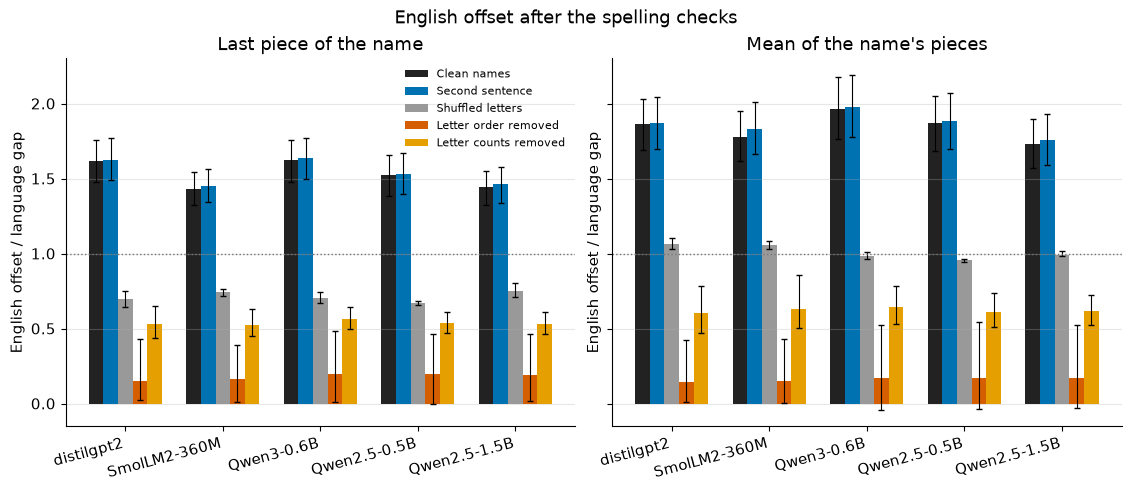

results/figures/english_spelling_checks.png


In [15]:
PUBLISH_FILES = [
    ("distilgpt2.json", "distilgpt2"),
    ("HuggingFaceTB__SmolLM2-360M.json", "SmolLM2-360M"),
    ("Qwen__Qwen3-0.6B.json", "Qwen3-0.6B"),
    ("Qwen__Qwen2.5-0.5B.json", "Qwen2.5-0.5B"),
    ("Qwen__Qwen2.5-1.5B.json", "Qwen2.5-1.5B"),
]
if "Qwen2.5-1.5B" not in COLORS:
    COLORS["Qwen2.5-1.5B"] = "#D55E00"
publish = []
for filename, label in PUBLISH_FILES:
    path = ROOT / "results" / "publish" / filename
    if not path.exists():
        continue
    payload = json.loads(path.read_text())
    if payload.get("error"):
        raise RuntimeError(f"{label}: {payload['error']}")
    payload["label"] = label
    publish.append(payload)
if not publish:
    raise FileNotFoundError("results/publish is empty")

def condition_value(block, name):
    clean = block["clean"]
    if name == "clean":
        point = clean["english_orthogonal_over_language_gap"]
        low, high = clean["bootstrap"]["centroid_ratio"]["ci95"]
    elif name == "prompt":
        item = block["second_prompt"]
        point = item["english_orthogonal_over_language_gap"]
        low, high = item["bootstrap"]["centroid_ratio"]["ci95"]
    elif name == "shuffle":
        draws = [item["english_orthogonal_over_language_gap"] for item in block["shuffled"]["at_clean_layer"]]
        point = float(np.mean(draws))
        low, high = min(draws), max(draws)
    elif name == "order":
        item = clean["residual"]["char_2_3gram"]
        point = item["english_orthogonal_over_language_gap"]
        low, high = item["bootstrap"]["centroid_ratio"]["ci95"]
    elif name == "letters":
        item = clean["residual"]["char_unigram"]
        point = item["english_orthogonal_over_language_gap"]
        low, high = item["bootstrap"]["centroid_ratio"]["ci95"]
    else:
        raise KeyError(name)
    return point, point - low, high - point

CONDITIONS = [
    ("clean", "Clean names", "#222222"),
    ("prompt", "Second sentence", "#0072B2"),
    ("shuffle", "Shuffled letters", "#999999"),
    ("order", "Letter order removed", "#D55E00"),
    ("letters", "Letter counts removed", "#E69F00"),
]
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), sharey=True, constrained_layout=True)
x = np.arange(len(publish))
width = 0.15
for ax, site, title in zip(axes, ("last", "mean"), ("Last piece of the name", "Mean of the name's pieces")):
    for index, (key, label, color) in enumerate(CONDITIONS):
        points, lows, highs = [], [], []
        for run in publish:
            point, low, high = condition_value(run["sites"][site], key)
            points.append(point)
            lows.append(low)
            highs.append(high)
        offset = (index - (len(CONDITIONS) - 1) / 2) * width
        ax.bar(
            x + offset,
            points,
            width,
            yerr=np.vstack([lows, highs]),
            color=color,
            label=label,
            capsize=2,
            error_kw={"linewidth": 0.8},
        )
    ax.axhline(1, color="0.45", linewidth=1, linestyle=":")
    ax.set_title(title)
    ax.set_xticks(x, [run["label"] for run in publish], rotation=15, ha="right")
    ax.set_ylabel("English offset / language gap")
    ax.yaxis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("English offset after the spelling checks")
finish(fig, "english_spelling_checks.png")


## The offset across layers

The clean names and the second sentence stay above one language-gap at every layer. Shuffling letters and removing character 2–3 grams pull the offset down. The band on the shuffled curve is the range across three shuffles.

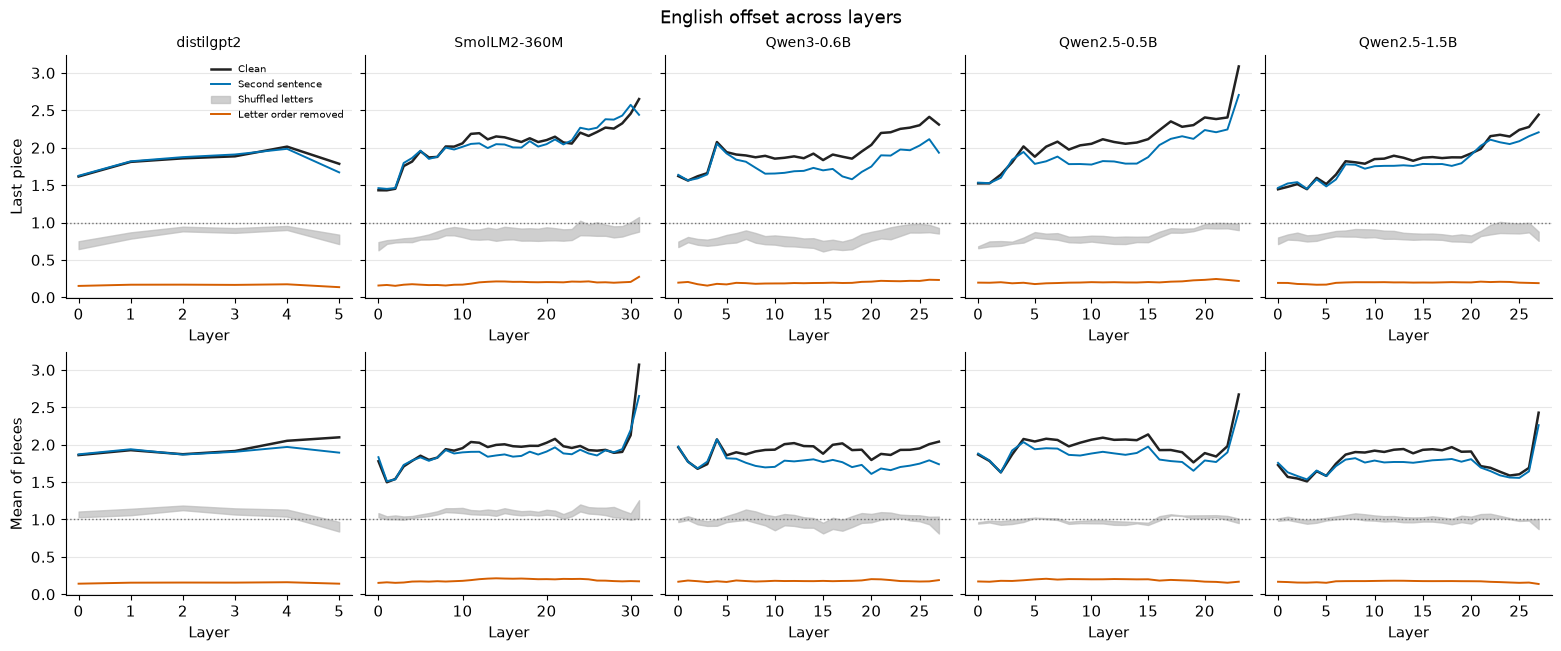

results/figures/english_offset_by_layer.png


In [16]:
fig, axes = plt.subplots(2, len(publish), figsize=(3.1 * len(publish), 6.4), sharey=True, constrained_layout=True)
axes = np.atleast_2d(axes)
for column, run in enumerate(publish):
    for row, site in enumerate(("last", "mean")):
        ax = axes[row, column]
        block = run["sites"][site]
        clean = block["clean"]["by_layer"]
        layers = [item["layer"] for item in clean]
        ax.plot(layers, [item["english_orthogonal_over_language_gap"] for item in clean], color="#222222", linewidth=1.8, label="Clean")
        prompt = block["second_prompt"]["by_layer"]
        ax.plot(layers, [item["english_orthogonal_over_language_gap"] for item in prompt], color="#0072B2", linewidth=1.4, label="Second sentence")
        band = block["shuffled"]["band"]
        ax.fill_between(band["layer"], band["centroid_min"], band["centroid_max"], color="#bbbbbb", alpha=0.7, label="Shuffled letters")
        residual = block["clean"]["residual"]["char_2_3gram"]["by_layer"]
        ax.plot(layers, [item["english_orthogonal_over_language_gap"] for item in residual], color="#D55E00", linewidth=1.4, label="Letter order removed")
        ax.axhline(1, color="0.45", linewidth=1, linestyle=":")
        if row == 0:
            ax.set_title(run["label"], fontsize=10)
        if column == 0:
            ax.set_ylabel("Last piece" if site == "last" else "Mean of pieces")
        ax.set_xlabel("Layer")
        ax.yaxis.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=7)
fig.suptitle("English offset across layers")
finish(fig, "english_offset_by_layer.png")


## Language gaps and spelling gaps

Each point in the correlation is one pair among the six languages. The activation distance is the gap between training centroids. The spelling distance is the gap between their character-count vectors. Letter counts track which languages sit near each other. Letter order does not.

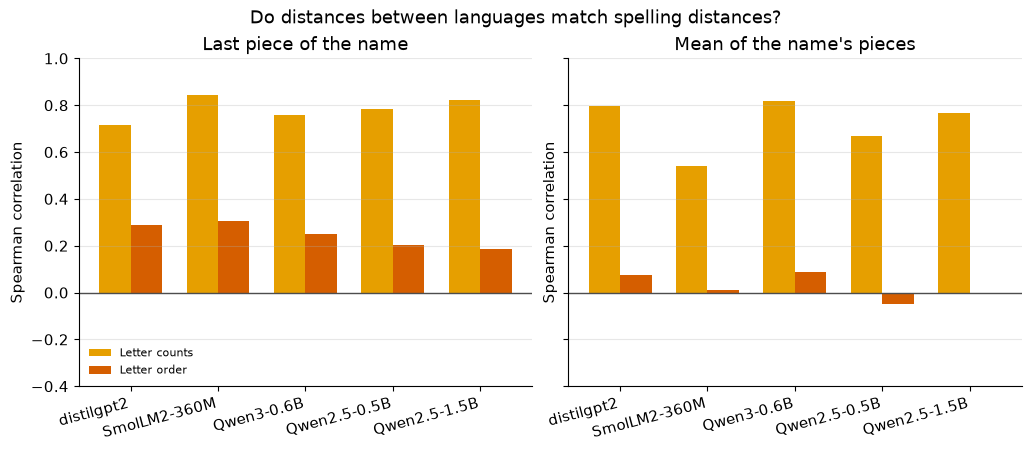

results/figures/language_gap_vs_spelling.png
model            site   clean              shuffle  order    counts   prompt   rho counts rho order
distilgpt2       last   1.62 [1.48,1.76]  0.70    0.15    0.53    1.63    0.71      0.29
distilgpt2       mean   1.86 [1.69,2.03]  1.06    0.14    0.61    1.87    0.80      0.07
SmolLM2-360M     last   1.43 [1.32,1.54]  0.74    0.17    0.53    1.45    0.84      0.31
SmolLM2-360M     mean   1.78 [1.62,1.95]  1.06    0.15    0.63    1.83    0.54      0.01
Qwen3-0.6B       last   1.62 [1.48,1.75]  0.70    0.20    0.56    1.64    0.76      0.25
Qwen3-0.6B       mean   1.97 [1.77,2.18]  0.98    0.17    0.64    1.98    0.82      0.09
Qwen2.5-0.5B     last   1.52 [1.39,1.66]  0.67    0.20    0.54    1.53    0.78      0.20
Qwen2.5-0.5B     mean   1.87 [1.69,2.05]  0.95    0.17    0.61    1.88    0.67      -0.05
Qwen2.5-1.5B     last   1.44 [1.32,1.55]  0.75    0.19    0.53    1.46    0.82      0.19
Qwen2.5-1.5B     mean   1.73 [1.57,1.89]  0.99    0.1

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4), sharey=True, constrained_layout=True)
x = np.arange(len(publish))
width = 0.36
for ax, site, title in zip(axes, ("last", "mean"), ("Last piece of the name", "Mean of the name's pieces")):
    for offset, key, label, color in (
        (-width / 2, "char_unigram", "Letter counts", "#E69F00"),
        (width / 2, "char_2_3gram", "Letter order", "#D55E00"),
    ):
        values = [run["sites"][site]["clean"]["spelling_distance"][key]["spearman"] for run in publish]
        ax.bar(x + offset, values, width, color=color, label=label)
    ax.axhline(0, color="0.3", linewidth=1)
    ax.set_ylim(-0.4, 1)
    ax.set_title(title)
    ax.set_xticks(x, [run["label"] for run in publish], rotation=15, ha="right")
    ax.set_ylabel("Spearman correlation")
    ax.yaxis.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Do distances between languages match spelling distances?")
finish(fig, "language_gap_vs_spelling.png")

print(f"{'model':16} {'site':6} {'clean':18} {'shuffle':8} {'order':8} {'counts':8} {'prompt':8} {'rho counts':10} {'rho order':9}")
for run in publish:
    for site in ("last", "mean"):
        block = run["sites"][site]
        clean = block["clean"]
        low, high = clean["bootstrap"]["centroid_ratio"]["ci95"]
        shuffle = np.mean([item["english_orthogonal_over_language_gap"] for item in block["shuffled"]["at_clean_layer"]])
        order = clean["residual"]["char_2_3gram"]["english_orthogonal_over_language_gap"]
        counts = clean["residual"]["char_unigram"]["english_orthogonal_over_language_gap"]
        prompt = block["second_prompt"]["english_orthogonal_over_language_gap"]
        rho1 = clean["spelling_distance"]["char_unigram"]["spearman"]
        rho2 = clean["spelling_distance"]["char_2_3gram"]["spearman"]
        print(
            f"{run['label']:16} {site:6} {clean['english_orthogonal_over_language_gap']:.2f} [{low:.2f},{high:.2f}]  "
            f"{shuffle:.2f}    {order:.2f}    {counts:.2f}    {prompt:.2f}    {rho1:.2f}      {rho2:.2f}"
        )
